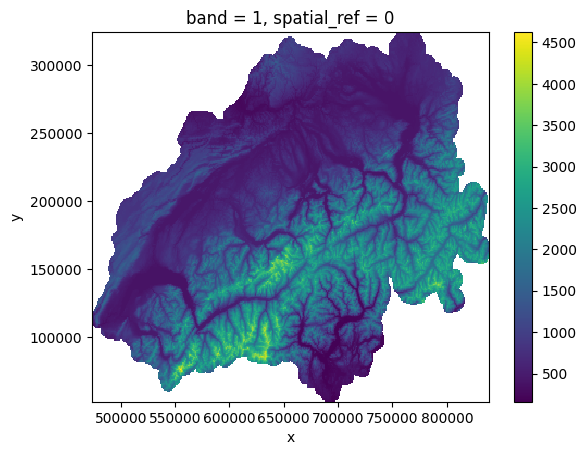

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import xarray as xr
import matplotlib
import platform
import cartopy.crs as ccrs
import cartopy.io.shapereader as shapereader
import rioxarray
import glob

# set font type for PDFs and EPSs
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# make switch to windows if working from home
if platform.system() == 'Windows':
    base_dir = Path('L:\malle\CLM5_CH')
else:
    base_dir = Path('/home/lud11/malle/CLM5_CH')

dem_hyp = [150, range(400,3000,100)]
dem_file = base_dir / 'BAFU_DEM_2020_1000.txt'
dem_array = rioxarray.open_rasterio(dem_file, parse_coordinates=True, masked=True)

bf_oshd = base_dir / 'FSM_new/analysed_grid_python_out'
all_FSM = xr.open_mfdataset(glob.glob(str(bf_oshd / '*025*')))

bf_out = base_dir / 'figures_revisions'

In [ ]:
run_in_all_1km = ['CRUJRA_FILES_noLapse_OLD', 'CRUJRA_FILES_noLapse',
                  'CRUJRA_FILES_OLD', 'CRUJRA_FILES', 'OSHD_FILES_OLD', 'OSHD_FILES']

run_in_coarse = ['CRUJRA_FILES_05deg_cru_new', 'CRUJRA_FILES_05deg_cru_new_lapse', 'OSHD_FILES_05_new',
                 'CRUJRA_FILES_025deg_cru_new', 'CRUJRA_FILES_025deg_cru_new_lapse', 'OSHD_FILES_025_new']

label_in = ['FSM', 'Clim$_{CRU0.5^{\circ}}$+LU$_{Gl0.5^{\circ}}$', 'Clim$_{CRU^{*}0.5^{\circ}}$+LU$_{Gl0.5^{\circ}}$',
            'Clim$_{OSHD0.5^{\circ}}$+LU$_{Gl0.5^{\circ}}$',
            'Clim$_{CRU0.25^{\circ}}$+LU$_{Gl0.25^{\circ}}$', 'Clim$_{CRU^{*}0.25^{\circ}}$+LU$_{Gl0.25^{\circ}}$',
            'Clim$_{OSHD0.25^{\circ}}$+LU$_{Gl0.25^{\circ}}$',
            'Clim$_{CRU1km}$+LU$_{Gl1km}$', 'Clim$_{CRU1km}$+LU$_{HR1km}$',
            'Clim$_{CRU^{*}1km}$+LU$_{Gl1km}$', 'Clim$_{CRU^{*}1km}$+LU$_{HR1km}$',
            'Clim$_{OSHD1km}$+LU$_{Gl1km}$', 'Clim$_{OSHD1km}$+LU$_{HR1km}$'
            ]

run_in_all = run_in_coarse + run_in_all_1km
snow_in_025 = '*_025_SNOW_DEPTH*'

for run_in in run_in_all:
    if (run_in == 'CRUJRA_FILES_025deg_cru_new' or run_in == 'CRUJRA_FILES_025deg_cru_new_lapse' or
            run_in == 'OSHD_FILES_025_new'):
        snow_in_comp = xr.open_dataset(glob.glob(str(base_dir / 'OSHD_FILES' / snow_in_025))[0])
        snow_in = xr.open_dataset(glob.glob(str(base_dir / run_in / 'SNOW_DEPTH*'))[0])
        snow_in = snow_in.where(~np.isnan(snow_in_comp.DATA).values, np.nan)
    elif (run_in == 'CRUJRA_FILES_05deg_cru_new' or run_in == 'CRUJRA_FILES_05deg_cru_new_lapse' or
          run_in == 'OSHD_FILES_05_new'):
        snow_in_comp = xr.open_dataset(glob.glob(str(base_dir / 'OSHD_FILES' / snow_in_025))[0])
        snow_in = xr.open_dataset(glob.glob(str(base_dir / run_in / snow_in_025))[0])
        snow_in = snow_in.where(~np.isnan(snow_in_comp.DATA).values, np.nan)
    else:
        snow_in = xr.open_dataset(glob.glob(str(base_dir / run_in / snow_in_025))[0])